# Question 7: PCA and Kernel PCA on Structured Data


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA

## a: PCA on Iris Dataset
### 1. Load and Standardize Data

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

### 2. Apply PCA and Compute Eigenvalues

In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

print("Eigenvalues (Explained Variance):", pca.explained_variance_)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Eigenvalues (Explained Variance): [2.93808505 0.9201649 ]
Explained Variance Ratio: [0.72962445 0.22850762]


### 3. Visualize PCA Result

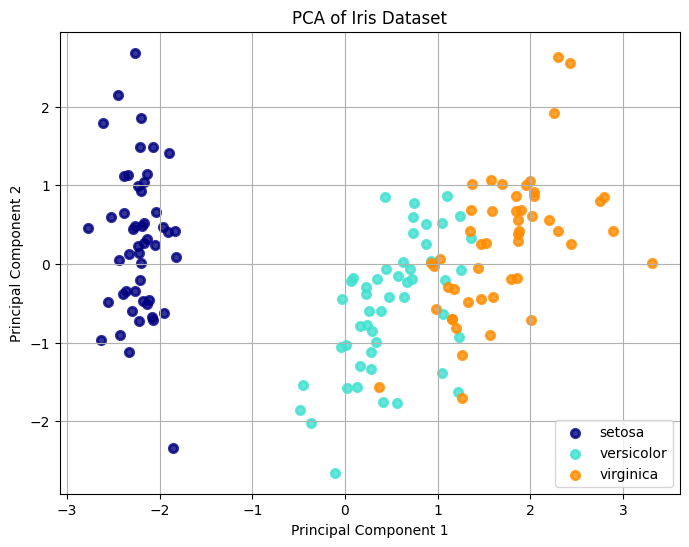

In [4]:
plt.figure(figsize=(8, 6))
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, alpha=.8, lw=lw,
                label=target_name)
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.grid(True)
plt.show()

## Part (b): Nonlinear Data (Nested Circles)
### 1. Generate Two-Dimensional Dataset

In [5]:
X_circles, y_circles = make_circles(n_samples=400, factor=.3, noise=.05, random_state=0)

### 2. Apply Standard PCA and Kernel PCA (RBF Kernel)

In [6]:
pca_circles = PCA(n_components=2)
X_pca_circles = pca_circles.fit_transform(X_circles)

kpca = KernelPCA(kernel="rbf", fit_inverse_transform=False, gamma=10)
X_kpca_circles = kpca.fit_transform(X_circles)

### 3. Visualize and Compare Projections

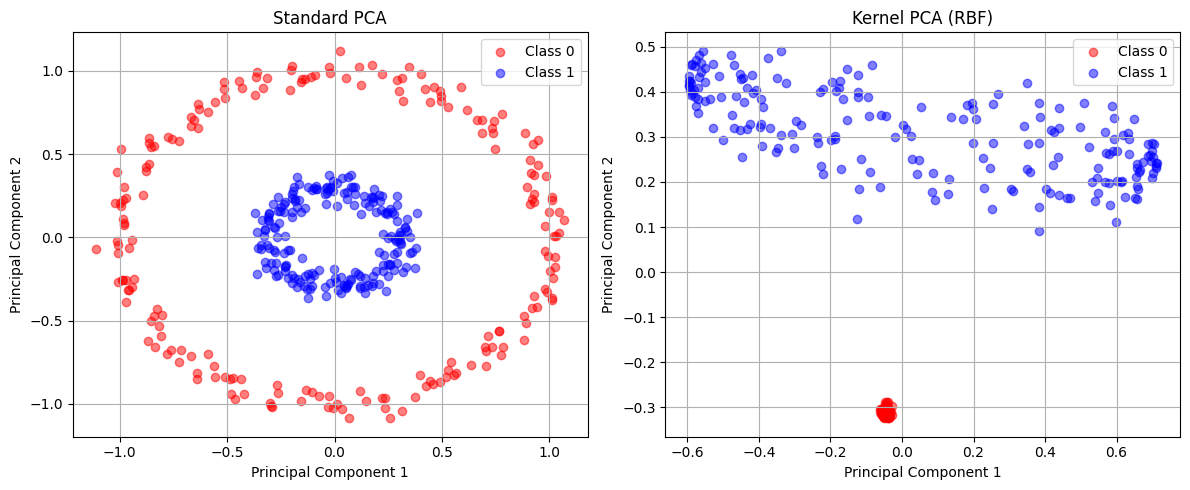

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca_circles[y_circles == 0, 0], X_pca_circles[y_circles == 0, 1], color='red', alpha=0.5, label='Class 0')
plt.scatter(X_pca_circles[y_circles == 1, 0], X_pca_circles[y_circles == 1, 1], color='blue', alpha=0.5, label='Class 1')
plt.title('Standard PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X_kpca_circles[y_circles == 0, 0], X_kpca_circles[y_circles == 0, 1], color='red', alpha=0.5, label='Class 0')
plt.scatter(X_kpca_circles[y_circles == 1, 0], X_kpca_circles[y_circles == 1, 1], color='blue', alpha=0.5, label='Class 1')
plt.title('Kernel PCA (RBF)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()